In [59]:
import json
import pickle
from pathlib import Path
from typing import Dict, List, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
BASE_ARTIFACTS_DIR = Path("artifacts")
OUTPUT_DIR = Path("notebook/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts root: {BASE_ARTIFACTS_DIR.resolve()}")
print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")

Artifacts root: /Users/samuel/nfl-model-platform/artifacts
Outputs will be saved to: /Users/samuel/nfl-model-platform/notebook/outputs


In [60]:
def find_artifact_dirs(base_dir: Path = BASE_ARTIFACTS_DIR) -> List[Path]:
    if not base_dir.exists():
        print(f"No artifacts directory found at {base_dir.resolve()}")
        return []
    runs: List[Path] = []
    for model_dir in base_dir.iterdir():
        if model_dir.is_dir():
            for version_dir in model_dir.iterdir():
                if version_dir.is_dir():
                    runs.append(version_dir)
    return sorted(runs)


def _metric_from_metadata(meta: Dict[str, object]) -> Dict[str, object]:
    metric_keys = [
        "holdout_rmse",
        "holdout_mae",
        "baseline_rmse",
        "best_cv_rmse",
        "beat_baseline",
    ]
    metrics = {k: meta.get(k) for k in metric_keys if k in meta}
    metrics["train_rows"] = meta.get("train_rows")
    metrics["holdout_rows"] = meta.get("holdout_rows")
    metrics["n_estimators"] = meta.get("n_estimators")
    return metrics


def load_metadata(artifact_dir: Path) -> Optional[Dict[str, object]]:
    meta_path = artifact_dir / "metadata.json"
    if not meta_path.exists():
        print(f"No metadata.json found in {artifact_dir}")
        return None
    with meta_path.open() as f:
        meta = json.load(f)
    meta["artifact_dir"] = str(artifact_dir)
    meta.setdefault("model_name", artifact_dir.parent.name)
    meta.setdefault("version", artifact_dir.name)
    return meta


def metadata_row(meta: Dict[str, object]) -> pd.DataFrame:
    metrics = _metric_from_metadata(meta)
    row = {
        "model_name": meta.get("model_name"),
        "version": meta.get("version"),
        "saved_at": meta.get("saved_at"),
        **metrics,
    }
    best_params = meta.get("best_params")
    if isinstance(best_params, dict):
        row["best_params"] = json.dumps(best_params)
    return pd.DataFrame([row])


def load_eval_results(artifact_dir: Path) -> pd.DataFrame:
    candidates = [
        artifact_dir / "evaluation.json",
        artifact_dir / "eval.json",
        artifact_dir / "metrics.json",
        artifact_dir / "metrics.csv",
    ]
    for path in candidates:
        if path.exists():
            if path.suffix == ".csv":
                df = pd.read_csv(path)
            else:
                with path.open() as f:
                    payload = json.load(f)
                if isinstance(payload, list):
                    df = pd.DataFrame(payload)
                else:
                    df = pd.DataFrame([payload])
            df["artifact_dir"] = str(artifact_dir)
            return df
    meta = load_metadata(artifact_dir)
    if meta is None:
        return pd.DataFrame()
    metrics = _metric_from_metadata(meta)
    tidy = pd.DataFrame(
        [
            {"metric": k, "value": v, "artifact_dir": str(artifact_dir)}
            for k, v in metrics.items()
            if v is not None
        ]
    )
    return tidy

In [61]:
artifact_dirs = find_artifact_dirs()
print(f"Found {len(artifact_dirs)} artifact runs")
if artifact_dirs:
    for idx, run in enumerate(artifact_dirs, start=1):
        print(f"{idx:02d}: {run}")
selected_artifact_dir = artifact_dirs[0] if artifact_dirs else BASE_ARTIFACTS_DIR
print(f"Selected run: {selected_artifact_dir}")

all_meta_rows: List[pd.DataFrame] = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if meta:
        all_meta_rows.append(metadata_row(meta))
metadata_df = pd.concat(all_meta_rows, ignore_index=True) if all_meta_rows else pd.DataFrame()
metadata_df

Found 1 artifact runs
01: artifacts/player_projection/v1
Selected run: artifacts/player_projection/v1


,model_name,version,saved_at,holdout_rmse,holdout_mae,baseline_rmse,best_cv_rmse,beat_baseline,train_rows,holdout_rows,n_estimators,best_params
0,player_projection,v1,2026-03-23T00:01:38.507633+00:00,2.9295,1.18,14.9148,5.5125,True,4053,823,387,"{""learning_rate"": 0.07725378389307355, ""max_de..."


In [62]:
eval_frames: List[pd.DataFrame] = []
for run in artifact_dirs:
    df = load_eval_results(run)
    if not df.empty:
        df["model_name"] = run.parent.name
        df["version"] = run.name
        eval_frames.append(df)
eval_df = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
display(eval_df.head())
print(f"Eval rows: {len(eval_df)}")

,metric,value,artifact_dir,model_name,version
0,holdout_rmse,2.9295,artifacts/player_projection/v1,player_projection,v1
1,holdout_mae,1.18,artifacts/player_projection/v1,player_projection,v1
2,baseline_rmse,14.9148,artifacts/player_projection/v1,player_projection,v1
3,best_cv_rmse,5.5125,artifacts/player_projection/v1,player_projection,v1
4,beat_baseline,True,artifacts/player_projection/v1,player_projection,v1


Eval rows: 8


metric,model_name,version,baseline_rmse,beat_baseline,best_cv_rmse,holdout_mae,holdout_rmse,holdout_rows,n_estimators,train_rows
0,player_projection,v1,14.9148,1.0,5.5125,1.18,2.9295,823.0,387.0,4053.0


,metric,count,mean,std,min,max
0,baseline_rmse,1,14.9148,NaN,14.9148,14.9148
1,beat_baseline,1,1.0,NaN,True,True
2,best_cv_rmse,1,5.5125,NaN,5.5125,5.5125
3,holdout_mae,1,1.18,NaN,1.18,1.18
4,holdout_rmse,1,2.9295,NaN,2.9295,2.9295
5,holdout_rows,1,823.0,NaN,823,823
6,n_estimators,1,387.0,NaN,387,387
7,train_rows,1,4053.0,NaN,4053,4053


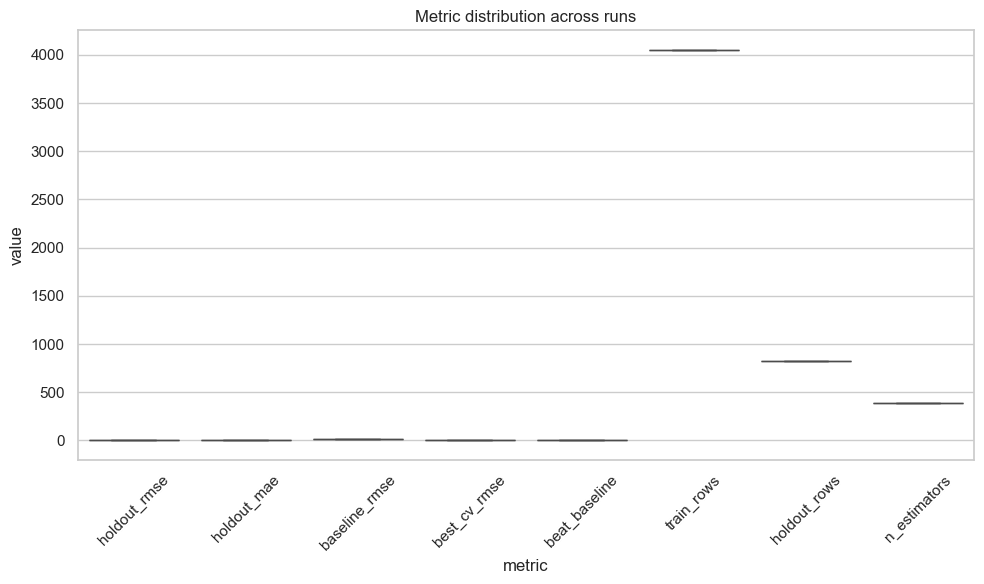

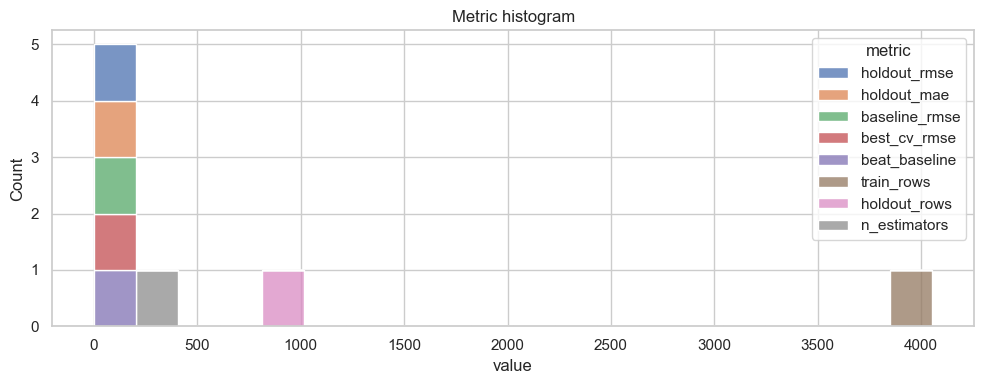

In [63]:
if not eval_df.empty:
    metrics_table = eval_df.pivot_table(
        index=["model_name", "version"],
        columns="metric",
        values="value",
        aggfunc="mean",
    ).reset_index()
    display(metrics_table)

    agg_metrics = eval_df.groupby("metric")["value"].agg(["count", "mean", "std", "min", "max"]).reset_index()
    display(agg_metrics)

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=eval_df, x="metric", y="value")
    plt.xticks(rotation=45)
    plt.title("Metric distribution across runs")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.histplot(data=eval_df, x="value", hue="metric", multiple="stack", bins=20)
    plt.title("Metric histogram")
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation data found; please add evaluation.json/metrics files or ensure metadata contains metrics.")

Columns after reset: ['player_name', 'draft_year', 'forty_yard', 'vertical_in', 'bench_reps', 'broad_jump_in', 'three_cone', 'shuttle', 'height_in', 'weight_lbs', 'speed_score', 'agility_score', 'burst_score', 'strength_score', 'size_score', 'draft_value_score', 'draft_value_percentile', 'age', 'pos_QB', 'pos_SKILL', 'pos_OL', 'pos_DL', 'pos_LB', 'pos_DB', 'pos_SPEC', 'missing_forty_yard', 'missing_vertical_in', 'missing_bench_reps', 'missing_broad_jump_in', 'missing_three_cone', 'missing_shuttle', 'round_x_draft_value', '_car_av', 'artifact_dir']
val            _car_av
count  1155.000000
mean     19.077922
std      19.869090
min       0.000000
25%       4.000000
50%      12.000000
75%      30.000000
max     115.000000
holdout        _car_av
count      0.0
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN


/var/folders/t8/_2vv47_s12d49vpmvrkng3c80000gn/T/ipykernel_98009/3964485488.py:33: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=hold_df, x=target_col, label="holdout", fill=True)


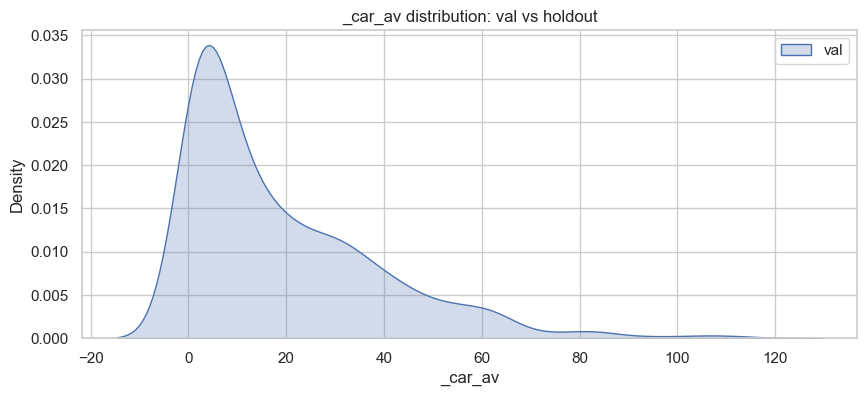

In [86]:
def load_feature_data(artifact_dir: Path) -> Optional[pd.DataFrame]:
    parquet_path = artifact_dir / "train_features.parquet"
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        df["artifact_dir"] = str(artifact_dir)
        return df
    print(f"No train_features.parquet found in {artifact_dir}")
    return None


features_df = load_feature_data(selected_artifact_dir)

# val vs holdout
features_df = load_feature_data(selected_artifact_dir)
if features_df is not None:
    features_df = features_df.reset_index()  # brings draft_year/player_name out of the index
    target_col = "_car_av"
    year_col = "draft_year"
    print("Columns after reset:", features_df.columns.tolist())
else:
    target_col = "_car_av"
    year_col = "draft_year"
if features_df is not None and target_col in features_df.columns and year_col in features_df.columns:
    val_years = [2015, 2016, 2017, 2018, 2019, 2020]
    holdout_years = [2021, 2022]
    def subset(years):
        return features_df[features_df[year_col].isin(years)]
    val_df, hold_df = subset(val_years), subset(holdout_years)
    for name, df in [("val", val_df), ("holdout", hold_df)]:
        print(name, df[[target_col]].describe())
    plt.figure(figsize=(10,4))
    sns.kdeplot(data=val_df, x=target_col, label="val", fill=True)
    sns.kdeplot(data=hold_df, x=target_col, label="holdout", fill=True)
    plt.title(f"{target_col} distribution: val vs holdout")
    plt.legend()
    plt.show()
else:
    missing = [c for c in [target_col, year_col] if c not in (features_df.columns if features_df is not None else [])]
    print("Missing columns:", missing)

# print(features_df.columns.tolist())
# print(features_df.head())


Loaded model from artifacts/player_projection/v1/model.pkl
SHAP sample shape: (500, 30), NaN rows: 500


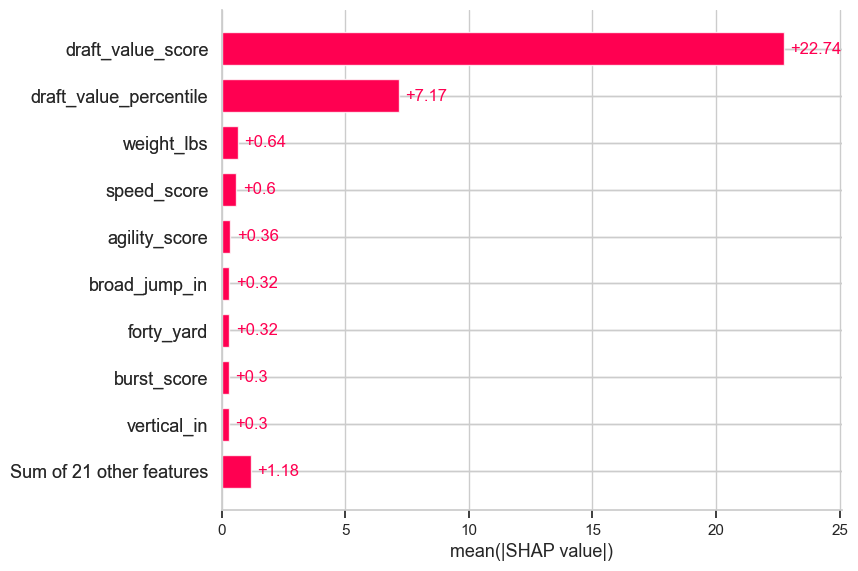

In [ ]:
model = load_model(selected_artifact_dir)
selected_meta = load_metadata(selected_artifact_dir)
if model is not None and features_df is not None:
    import shap

    feature_cols = (
        selected_meta["feature_names"] if (selected_meta and "feature_names" in selected_meta)
        else list(model.feature_names_in_) if hasattr(model, "feature_names_in_")
        else [c for c in features_df.columns if c not in ["car_av", "artifact_dir", "pos", "draft_round", "year"]]
    )

    shap_sample = (
        features_df[feature_cols]
        .sample(n=min(500, len(features_df)), random_state=42)
        .astype(float)
        .reset_index(drop=True)
    )
    print(f"SHAP sample shape: {shap_sample.shape}, NaN rows: {shap_sample.isna().any(axis=1).sum()}")

    try:
        explainer = shap.Explainer(model, shap_sample)
        sv = explainer(shap_sample)
        shap.plots.bar(sv)
    except Exception as e1:
        print(f"shap.Explainer failed ({e1}), falling back to XGBoost native pred_contribs …")
        try:
            import xgboost as xgb
            dm = xgb.DMatrix(shap_sample, feature_names=feature_cols)
            contribs = model.get_booster().predict(dm, pred_contribs=True)
            # contribs shape: (n_samples, n_features + 1) — last col is bias
            mean_abs = np.abs(contribs[:, :-1]).mean(axis=0)
            fi_df = (
                pd.DataFrame({"feature": feature_cols, "mean_|SHAP|": mean_abs})
                .sort_values("mean_|SHAP|", ascending=False)
            )
            plt.figure(figsize=(10, 6))
            sns.barplot(data=fi_df.head(20), x="mean_|SHAP|", y="feature")
            plt.title("Mean |SHAP| value (XGBoost native pred_contribs)")
            plt.tight_layout()
            plt.show()
        except Exception as e2:
            print(f"Native pred_contribs also failed: {e2}")
else:
    print("Need model and features to compute SHAP.")

,train_end,val_start,val_end
0,2014,2015,2016
1,2016,2017,2018
2,2018,2019,2020


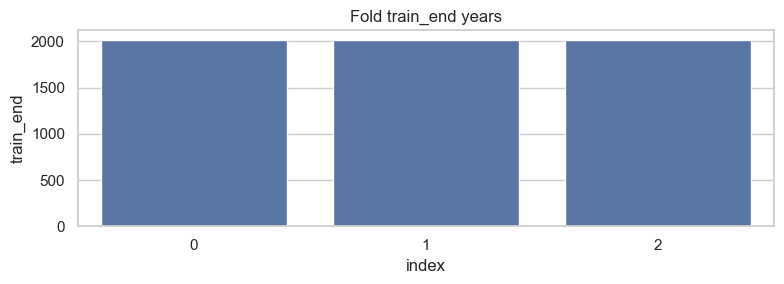

In [88]:
selected_meta = load_metadata(selected_artifact_dir)
if selected_meta and "folds" in selected_meta:
    folds_df = pd.DataFrame(selected_meta["folds"])
    display(folds_df)
    plt.figure(figsize=(8, 3))
    sns.barplot(data=folds_df.reset_index(), x="index", y="train_end")
    plt.title("Fold train_end years")
    plt.tight_layout()
    plt.show()
else:
    print("No fold info found in metadata.")

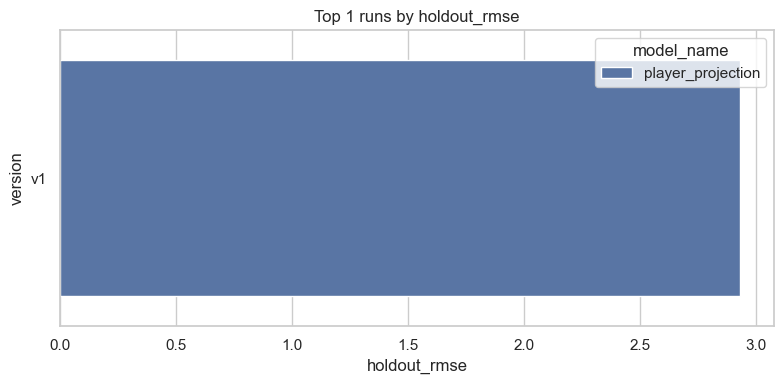

In [73]:
def plot_topk(models_table: pd.DataFrame, metric: str, k: int = 5, ascending: bool = True):
    if metric not in models_table.columns:
        print(f"Metric {metric} not found in table")
        return
    ordered = models_table.sort_values(metric, ascending=ascending).head(k)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=ordered, x=metric, y="version", hue="model_name")
    plt.title(f"Top {k} runs by {metric}")
    plt.tight_layout()
    plt.show()


if 'metrics_table' in locals():
    target_metric = 'holdout_rmse' if 'holdout_rmse' in metrics_table.columns else metrics_table.columns[-1]
    plot_topk(metrics_table, metric=target_metric, k=min(5, len(metrics_table)), ascending=True)
else:
    print("No metrics_table available for side-by-side comparison.")